Analisis Statistik Deskriptif Karakteristik URL pada Dataset Phishing

Anggota kelompok:
La Ode Muh. Baharizqi Ma'rufi - 5027261086
Marsha Daruningtyas - 5027261056
Farras Hazim Ramadhan - 5027261132

Topik yang dipilih: Cyber Security

In [1]:
# Import library dan membaca dataset
import pandas as pd
phising_df = pd.read_csv('./Dataset/Phising/dataset_phishing.csv')
phising_df.head()
# .head disini untuk membaca 5 baris pertama di dataset. jika ingin lebih maka cukup tambahkan saja angka di dalam kurungnya
# Phising_df adlaah variable
# pd read csv digunakan untuk membaca file csv yang saya simpan di /Dataset/Phising/dataset_phishing.csv

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [2]:
# Melihat ukuran dataset [baris] [kolom]
print(phising_df.shape)

(11430, 89)


Disini terlihat kalau dataset ini memiliki 11430 baris dan 89 kolom

In [3]:
# Melihat informasi dataset berupa struktur, tipe data kolom, dan jumlah nilai terisi
phising_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  str    
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde                    11430 non-null  int64  
 13  nb_percent                  11430 non-null

In [22]:
# Mengecek missing value [true false]
# Jika false berarti berisi dan true berarti tidak berisi
phising_df.isna()

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11425,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11426,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11427,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11428,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Disini tidak terlihat ada data yang bertuliskan "true". berarti tidak ada missing value di dataset ini
titik 3 (...) di tengah hanya berfungsi sebagai penyingkat dikarenakan barisnya yang sangat banyak (11430)

In [5]:
# Mengecek total missing value
phising_df.isna().sum()

url                0
length_url         0
length_hostname    0
ip                 0
nb_dots            0
                  ..
web_traffic        0
dns_record         0
google_index       0
page_rank          0
status             0
Length: 89, dtype: int64

Bisa dilihat ini 0 semua berarti tidak ada yang data yang kosong (missing value)

In [6]:
# Mengecek data duplikat
phising_df.duplicated().sum() 

np.int64(0)

Berdasarkan pengecekan, tidak ditemukan nilai kosong (missing value) maupun baris duplikat. Oleh karena itu, data siap digunakan tanpa perlu pembersihan lanjutan

In [7]:
# Membentuk list berisi nama 3 kolom numerik yang dipilih untuk analisis deskriptif
kolom_numerik = [
    "length_url",
    "length_hostname",
    "nb_dots"
]

1. length url artinya seberapa panjang url nya. situs web biasanya menggunakan url yang mudah diingat, sedangan pelaku phising menggunakan url yang lebih panjang karena memmuat sesuatu (berupa kata kata palsu atau kode unik untuk menipu korban). karena panjang url terlalu tinggi, sistem akan mendeteksinya sebagai ancaman (dalam kasus ini link phising).
contoh: https://google.com vs http://com-security-update.xyz
karena terlalu panjang, maka sistem akan mendeteksinya sebagai sebuah ancaman.

2. length hostname artinya nama khusus di bagian hostname saja (domain utama + subdomain). Sama seperti URL, pelaku phising membuat length hostname yang panjang agar menyerupai perusahaan asli. Length hostname yang panjang juga mengindikasikan adanya penipuan (dalam kasus ini phising)
contoh: ://tokopedia.com vs ://paypal-update-security-login-system.com
link kedua memiliki length hostname yang terlalu panjang, oleh karena itu sistem mendeteksinya sebagai phising

3. nb_dots artinya jumlah karakter titik (.) yang ada di url. website pada umumnya menggunakan 3 karakter titik saja (seperti ://domain.com). namun, pelaku phising menggunakan subdomain dengan banyak titik untuk mengelabuhi targetnya  (misalnya: ://konfirmasi-data.com). Jika jumlah dots terlalu banyak, maka sistem akah mendeteksi bahwa link ini adalah phising

Bagaimana cara menghitung url length, hostname length dam nb dots?
gini caranya:

1. url length
   cukup dihitung semua karakternya (termasuk karakter khusus seperti (.), (/), (:), dll
   contoh: https://www.instagram.com/accounts/login -> totalnya ada 40 karakter
           https://instagram-security-verifications-panel.net/secure-login

2. hostname length
   sebelum menghitung, pisahkan nama domain utama dari struktur URL, kemudian hitung jumlah karakternya
   contoh: https://www.bi.go.id/id/default.aspx -> hapus "https://" dan "/id/default.aspx" dari url utama lalu hitung (www.bi.go.id totalnya ada 12) 
           https://login.facebook.com.akun-terverifikasi.id/masuk/aman.html -> pisahkan "https://" dan "/masuk/aman.html" dari url utama lalu hitung (login.facebook.com.akun-terverifikasi.id totalnya ada 40)

3. nb dots
   cukup hitung titiknya saya(bukan titik dua(:) ya)
   contoh: https://www.netflix.com -> ada 2 titik
           http://www.netflix.com.akun-update.login-bantuan.id/session/index.php -> ada 6 titik

   dari semuanya harusnya sudah terlihat bedanya

In [8]:
# Menampilkan 5 baris pertama khusus untuk 3 kolom numerik pilihan
phising_df[kolom_numerik].head()

,length_url,length_hostname,nb_dots
0,37,19,3
1,77,23,1
2,126,50,4
3,18,11,2
4,55,15,2


Terlihat kalau baris ketiga memiliki length_url sebanyak 126 karakter, length hostnaem sebanyak 50 karakter dan jumlah titik sebanyak 4 yang mengindikasikan kalau link tersebut sudah pasti phising.

In [9]:
# Membuat tabel untuk statistik
hasil = pd.DataFrame(index=[
    "Mean",
    "Median",
    "Mode",
    "Minimum",
    "Maximum",
    "Range",
    "Variance",
    "Standar Deviasi",
    "Q1",
    "Q3",
    "IQR"
])

In [10]:
# Menghitung statistik
for kolom in kolom_numerik: # Melakukan perulangan untuk menghitung nilai statistik deskriptif pada tiap kolom numerik
    data = phising_df[kolom] # Mengambil series data untuk kolom yang sedang diproses

    hasil[kolom] = [
        data.mean(), # Menghitung nilai rata-rata (Mean)
        data.median(), # Menghitung nilai tengah (Median)
        data.mode()[0], # Menghitung nilai modus (paling sering muncul)
        data.min(), # Menemukan nilai terkecil (Minimum)
        data.max(), # Menemukan nilai terbesar (Maksimum)
        data.max() - data.min(), # Menghitung jangkauan data (Range = Max - Min)
        data.var(), # Menghitung nilai varians sampel (pembagi n-1)
        data.std(), # Menghitung simpangan baku / standar deviasi sampel
        data.quantile(0.25), # Menghitung Kuartil Pertama / Q1 (persentil ke-25)
        data.quantile(0.75), # Menghitung Kuartil Ketiga / Q3 (persentil ke-75)
        data.quantile(0.75) - data.quantile(0.25)] # Menhitung Jangkauan Interkuartil (IQR = Q3 - Q1)

Kenapa disini tidak ada rumus matematiknyanya(kecuali range dan interkuartil)?
karena semuanya sudah terinclude dalam library pandas.

In [11]:
# Menampilkan hasil statistik dalam bentuk tabel
hasil


,length_url,length_hostname,nb_dots
Mean,61.126684,21.090289,2.480752
Median,47.000000,19.000000,2.000000
Mode,26.000000,16.000000,2.000000
Minimum,12.000000,4.000000,1.000000
Maximum,1641.000000,214.000000,24.000000
Range,1629.000000,210.000000,23.000000
Variance,3057.793382,116.147416,1.876040
Standar Deviasi,55.297318,10.777171,1.369686
Q1,33.000000,15.000000,2.000000
Q3,71.000000,24.000000,3.000000


----------------------------------------------------------------------------------

In [12]:
# Analisis length_url
kolom = phising_df["length_url"]

print("Rata-rata panjang URL:", kolom.mean())
print("Median panjang URL:", kolom.median())

Rata-rata panjang URL: 61.12668416447944
Median panjang URL: 47.0


In [13]:
# Analisis length_hostname
kolom = phising_df["length_hostname"]

print("Minimum:", kolom.min())
print("Maximum:", kolom.max())
print("Range:", kolom.max() - kolom.min())
print("Variance:", kolom.var()) # ukuran statistik yang menunjukkan seberapa jauh penyebaran nilai-nilai data dari nilai rata-ratanya
print("Standar Deviasi:", kolom.std()) # tingkat sebaran atau variasi nilai

Minimum: 4
Maximum: 214
Range: 210
Variance: 116.14741640101883
Standar Deviasi: 10.777171075983661


In [14]:
# Analisis nb_dots
kolom = phising_df["nb_dots"]

print("Rata-rata:", kolom.mean())
print("Standar Deviasi:", kolom.std())
print("Q1:", kolom.quantile(0.25))
print("Q3:", kolom.quantile(0.75))
print("IQR:", kolom.quantile(0.75) - kolom.quantile(0.25))

Rata-rata: 2.4807524059492563
Standar Deviasi: 1.3696862349823726
Q1: 2.0
Q3: 3.0
IQR: 1.0


In [15]:
# Varians manual
data = phising_df["length_url"].head(10)

rata_rata = data.mean()

jumlah = 0

for nilai in data:
    jumlah += (nilai - rata_rata) ** 2

varians_manual = jumlah / (len(data) - 1)

print("Varians manual:", varians_manual)
print("Varians pandas:", data.var())

Varians manual: 1346.7666666666669
Varians pandas: 1346.7666666666669


In [16]:
# --- Ringkasan Variabel Kategorik ---
# Mengambil kolom 'status' (phishing vs legitimate)
jumlah_status = phising_df["status"].value_counts()
persen_status = phising_df["status"].value_counts(normalize=True) * 100

tabel_kategorik = pd.DataFrame({
    'Frekuensi': jumlah_status, 
    'Persentase (%)': persen_status
})

print("Tabel Frekuensi dan Persentase Variabel Kategorik (Status):")
print(tabel_kategorik)

Tabel Frekuensi dan Persentase Variabel Kategorik (Status):
            Frekuensi  Persentase (%)
status                               
legitimate       5715            50.0
phishing         5715            50.0


Dataset ini memiliki sebaran kelas yang seimbang sempurna, dengan 5.715 URL legitimate (50%) dan 5.715 URL phishing (50%). Modus dari variabel ini bersifat dwimoda/bimodal karena kedua kategori memiliki frekuensi yang sama persis.

In [ ]:
untuk penjelasan ini kira kira sama seperti di atas

In [19]:
print("Rata-rata:", hasil.loc["Mean", "length_url"])
print("Median:", hasil.loc["Median", "length_url"])


Rata-rata: 61.12668416447944
Median: 47.0


In [20]:
hasil

,length_url,length_hostname,nb_dots
Mean,61.126684,21.090289,2.480752
Median,47.000000,19.000000,2.000000
Mode,26.000000,16.000000,2.000000
Minimum,12.000000,4.000000,1.000000
Maximum,1641.000000,214.000000,24.000000
Range,1629.000000,210.000000,23.000000
Variance,3057.793382,116.147416,1.876040
Standar Deviasi,55.297318,10.777171,1.369686
Q1,33.000000,15.000000,2.000000
Q3,71.000000,24.000000,3.000000


Nilai Mean pada seluruh kolom numerik (length_url, length_hostname, dan nb_dots) secara signifikan lebih besar daripada nilai Median-nya. Hal ini mengindikasikan bahwa distribusi ketiga variabel tersebut miring ke kanan (right-skewed) karena dipengaruhi oleh nilai-nilai ekstrem (outliers).

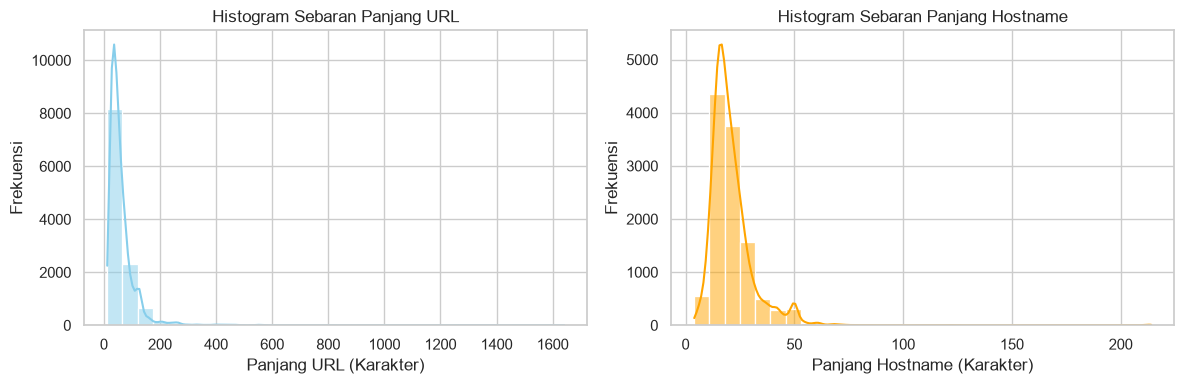

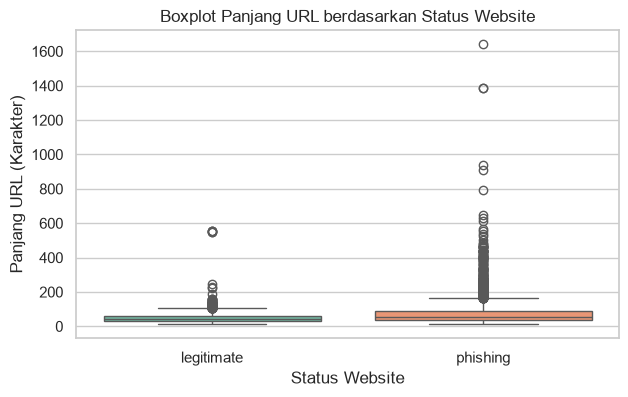

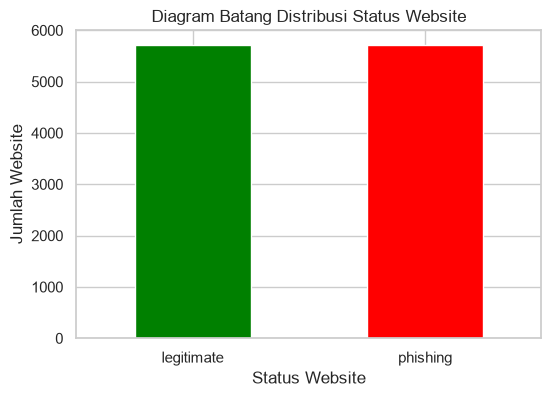

In [21]:
# Mengimpor pustaka matplotlib dan seaborn untuk pembuatan grafik visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tema tampilan grafik dengan latar belakang bergaris kisi (whitegrid)
sns.set_theme(style="whitegrid")

# --- 1. Histogram (2 Kolom Numerik: length_url dan length_hostname) ---
# Membuka figure berukuran 12x4 inch dengan 2 sub-plot bersampingan
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Membuat histogram dan kurva estimasi kepadatan (KDE) untuk kolom 'length_url'
sns.histplot(phising_df['length_url'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Histogram Sebaran Panjang URL")
axes[0].set_xlabel("Panjang URL (Karakter)")
axes[0].set_ylabel("Frekuensi")

# Membuat histogram dan kurva estimasi kepadatan (KDE) untuk kolom 'length_hostname'
sns.histplot(phising_df['length_hostname'], bins=30, kde=True, ax=axes[1], color='orange')
axes[1].set_title("Histogram Sebaran Panjang Hostname")
axes[1].set_xlabel("Panjang Hostname (Karakter)")
axes[1].set_ylabel("Frekuensi")

# Mengatur tata letak antar sub-plot agar tidak saling bertumpukan
plt.tight_layout()
plt.show()

# 2. Boxplot (1 Kolom Numerik: length_url per Status)
plt.figure(figsize=(7, 4))
# Memvisualisasikan pencilan (outliers) dan sebaran panjang URL berdasarkan kategori status
sns.boxplot(x='status', y='length_url', hue='status', data=phising_df, palette='Set2', legend=False)
plt.title("Boxplot Panjang URL berdasarkan Status Website")
plt.xlabel("Status Website")
plt.ylabel("Panjang URL (Karakter)")
plt.show()

# 3. Diagram Batang (1 Kolom Kategorik: status)
plt.figure(figsize=(6, 4))\
# Membuat diagram batang distribusi frekuensi status (hijau = legitimate, merah = phishing)
phising_df['status'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title("Diagram Batang Distribusi Status Website")
plt.xlabel("Status Website")
plt.ylabel("Jumlah Website")
plt.xticks(rotation=0) # Memastikan label sumbu x sejajar dan tidak miring
plt.show()